# Benchmarking and Evaluation

## Prepare Environment

Set up the notebook environment with necessary imports and create reusable utility functions for tasks we'll repeat across all datasets.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import optuna
import numpy as np
import pandas as pd
from scipy.stats import iqr
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge

import utils
from sgkan import sgkan_parameter_search as sps
from sgkan import sgkan_model
from hkan.hkan import (
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
)
import visualize
import swim as ss
import evaluation_metrics as em
random_seed = 0

/Users/gizemnurdal/miniconda3/envs/swim-meets-kans/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Helper functions for data handling, model evaluation, and statistical analysis across multiple runs.

In [2]:
def create_export_seed_results(seed_results, name):
    """Create dataframe from the seed results."""
    rows = []
    for i, r in enumerate(seed_results):
        rows.append({
            "seed": i,
            "train_mae": r["train"]["mae"],
            "train_rmse": r["train"]["rmse"],
            "train_inference_time_secs": r["train"]["inference_time_secs"],
            "test_mae": r["test"]["mae"],
            "test_rmse": r["test"]["rmse"],
            "test_inference_time_secs": r["test"]["inference_time_secs"],
        })

    seed_results_df = pd.DataFrame(rows)
    seed_results_df.to_csv(f"data/{name}.csv", index=False)
    return seed_results_df

def summarize_metrics(df, name):
    """Calculate IQR and Median values of RMSE and MAE metrics."""
    summary = {
        "model": name,
        "train_rmse_median": df["train_rmse"].median(),
        "train_rmse_iqr": iqr(df["train_rmse"]),
        "test_rmse_median": df["test_rmse"].median(),
        "test_rmse_iqr": iqr(df["test_rmse"]),
    }
    return summary


In [3]:
def run_sgkan_seed_experiments(x_train, y_train, x_test, y_test, layer_configs, n_runs=50):
    """Train SGKAN model n_runs times with different random seeds."""
    n_runs_results = []
    for s in range(n_runs):
        print(f"Seed: {s}")
        updated_configs = [config.copy() for config in layer_configs]
        for config in updated_configs:
            config['seed'] = s
        
        model = sgkan_model.SGKANModel(updated_configs).fit(x_train, y_train)
        results = em.evaluate(model, x_train, y_train, x_test, y_test)
        n_runs_results.append(results)
    
    return n_runs_results

In [4]:
def plot_hypothesis_1_results(results_df):
    """Plot Hypothesis 1 comparison results for SGKAN (swim), SGKAN (random), and HKAN."""
    plt.figure(figsize=(12, 6))

    plt.plot(results_df['layer_width'], results_df['sgkan_swim_train_rmse'], marker='o', label='SGKAN SWIM Train', color='#1f77b4')
    plt.plot(results_df['layer_width'], results_df['sgkan_swim_test_rmse'], marker='s', label='SGKAN SWIM Test', color='#1f77b4', linestyle='--')

    plt.plot(results_df['layer_width'], results_df['sgkan_random_train_rmse'], marker='o', label='SGKAN Random Train', color='#ff7f0e')
    plt.plot(results_df['layer_width'], results_df['sgkan_random_test_rmse'], marker='s', label='SGKAN Random Test', color='#ff7f0e', linestyle='--')

    plt.plot(results_df['layer_width'], results_df['hkan_train_rmse'], marker='o', label='HKAN Train', color='#2ca02c')
    plt.plot(results_df['layer_width'], results_df['hkan_test_rmse'], marker='s', label='HKAN Test', color='#2ca02c', linestyle='--')

    plt.xlabel('Layer Width')
    plt.ylabel('RMSE')
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_first_layer_local_edge_r2_summary(layer_neurons):
    """
    Boxplot of train-local R^2 across all nodes q, one box per input p,
    for the FIRST layer only. Unlike plot_first_layer_featurewise_r2_summary
    (which scores each edge against the full y_train), this scores each
    edge only against the local points it was actually fit on.
    """
    neurons = layer_neurons[0]
    n_vars_out = len(neurons)
    n_vars_in = len(neurons[0]["edge_params"])

    data, labels = [], []
    for p in range(n_vars_in):
        r2_vals = [
            r2_score(neurons[q]["edge_params"][p]["local_y"],
                     neurons[q]["edge_params"][p]["local_pred"])
            for q in range(n_vars_out)
        ]
        data.append(r2_vals)
        labels.append(f"p={p}")

    _, ax = plt.subplots(figsize=(1.5 * n_vars_in + 2, 4))
    ax.boxplot(data, tick_labels=labels, showmeans=True)
    ax.set_title(f"Layer 1: Local R² distribution per input variable ({n_vars_out} nodes)")
    ax.set_ylabel(r"$R^2$ (local)")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.show()

In [5]:
def load_dataset(dataset_prefix: str):
    """Load dataset using dataset prefix."""
    # base data directory
    DATA_DIR = os.path.join(os.getcwd(), "data")
    # load train and test set
    trn = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_trn.csv", delimiter=",")
    tst = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_tst.csv", delimiter=",")
    # slice train and test set
    x_train, y_train = trn[:, :-1], trn[:, -1]
    x_test,  y_test  = tst[:, :-1], tst[:, -1]
    
    print("x_train shape:", x_train.shape)
    print("y_train shape:", y_train.shape)
    print("x_test shape:", x_test.shape)
    print("y_test shape:", y_test.shape)

    return x_train, x_test, y_train, y_test

tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = load_dataset("tf1")
tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test = load_dataset("tf2")
tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = load_dataset("tf3")
tf4_x_train, tf4_x_test, tf4_y_train, tf4_y_test = load_dataset("tf4")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = load_dataset("tf5")

x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (3750, 10)
y_train shape: (3750,)
x_test shape: (1250, 10)
y_test shape: (1250,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)


## TF1

For TF1, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against HKAN's published results. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval_capped': 114, 'interval': 86}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval': 74, 'interval_capped': 26}
TF1 SGKAN train R2: 0.992241983672421


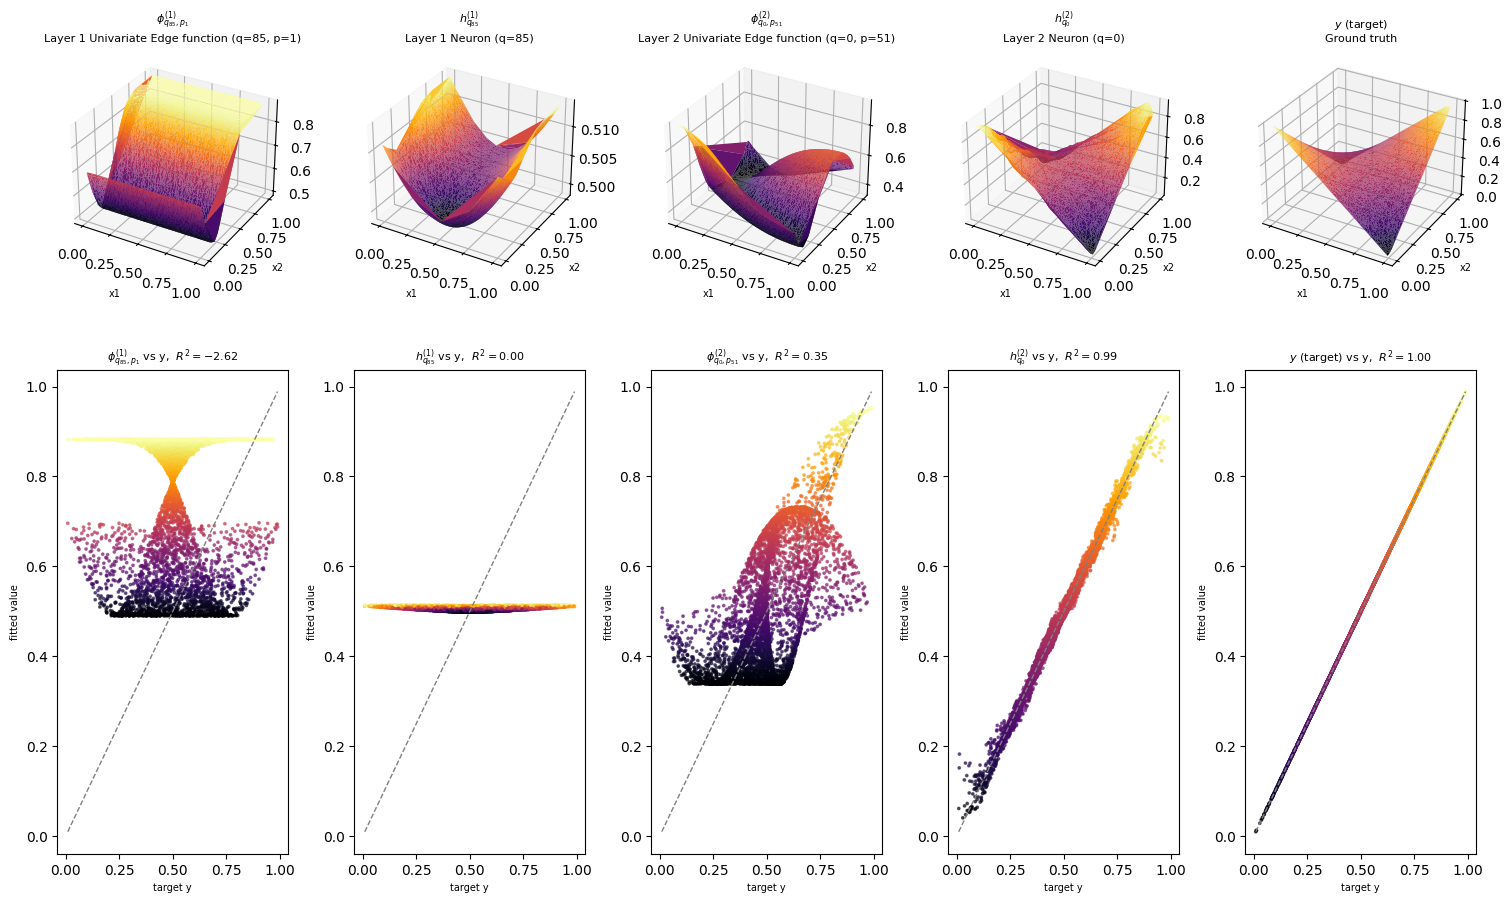

In [6]:
tf1_sgkan_layer_swim_configs = [
    {"layer_width": 100, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf1_sgkan_stages, tf1_sgkan_ytrain_hat, tf1_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf1_x_train, tf1_y_train, tf1_sgkan_layer_swim_configs)
print("TF1 SGKAN train R2:", r2_score(tf1_y_train, tf1_sgkan_ytrain_hat))

visualize.plot_model_stages(tf1_x_train, tf1_y_train, tf1_sgkan_stages, block_idx="random", seed=0)

In [7]:
tf1_sgkan_model = sgkan_model.SGKANModel(tf1_sgkan_layer_swim_configs).fit(tf1_x_train, tf1_y_train)

tf1_sgkan_results = em.evaluate(
    tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(tf1_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval_capped': 114, 'interval': 86}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval': 74, 'interval_capped': 26}
[SGKANModel.fit] Total fit duration: 2.5680s
Metric          Train                Test                
-------------------------------------------------------
MAE             1.063578e-02         1.130915e-02        
RMSE            1.464964e-02         1.637684e-02        
-------------------------------------------------------
Inference (s)   1.079924             2.158728            


### Optuna - Parameter Search 

Find the best layer configuration for TF1 dataset.

In [ ]:
tf1_result = sps.study_optuna_sgkan(
    "tf1", tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test,
    n_trials=375
)

In [ ]:
# Use best parameter configuration to fit an SGKAN model again
best_tf1_configs = tf1_result["layer_configs"]
best_tf1_configs

In [ ]:
tf1_sgkan_optuna_df = pd.read_csv("data/tf1_sgkan_optuna_search.csv")
tf1_sgkan_optuna_df.sort_values("val_rmse").head(5)

In [ ]:
best_tf1_sgkan_model = sgkan_model.SGKANModel(best_tf1_configs).fit(tf1_x_train, tf1_y_train)

best_tf1_sgkan_results = em.evaluate(
    best_tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(best_tf1_sgkan_results)

In [ ]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf1_configs = [
    {'layer_width': 1000,
    'num_inducing': 50,
    'pair_selection_strategy': 'random',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1},
    {'layer_width': 1,
    'num_inducing': 50,
    'pair_selection_strategy': 'random',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1
}]

In [ ]:
random_best_tf1_sgkan_model = sgkan_model.SGKANModel(random_best_tf1_configs).fit(tf1_x_train, tf1_y_train)

random_best_tf1_sgkan_results = em.evaluate(
    random_best_tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(random_best_tf1_sgkan_results)

### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE/MAE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [ ]:
# tf1_50_runs = run_sgkan_seed_experiments(tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, best_tf1_configs, n_runs=50)
# tf1_50_runs_df = create_export_seed_results(tf1_50_runs, "tf1_sgkan_50_run_results")
tf1_50_runs_df = pd.read_csv("data/tf1_sgkan_50_run_results.csv")
tf1_50_runs_df.head()

In [ ]:
summarize_metrics(tf1_50_runs_df, "SGKAN SWIM")

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [ ]:
# Best TF1 HKAN configuration from the paper
tf1_hkan_layer_configs = [
    dict(layer=0, n_vars_out=932, n_basis=2, centers="random_data_points", basis_fn=Sigmoid(s=1), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=1, n_basis=13, centers="random_data_points", basis_fn=Tanh(s=33), expanding_base_regressor=Ridge(alpha=10)),
]

In [ ]:
# # Define layer widths
# layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

# # Results storage
# results = {
#     'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
#     'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
#     'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
# }

# # SGKAN with SWIM
# print("Testing SGKAN with SWIM pair selection...")
# for width in layer_widths:
#     config = [c.copy() for c in best_tf1_configs]
#     config[0]['layer_width'] = width
#     model = sgkan_model.SGKANModel(config).fit(tf1_x_train, tf1_y_train)
#     eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
#     results['sgkan_swim']['widths'].append(width)
#     results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
#     results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
#     print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# # SGKAN with random pair selection
# print("\nTesting SGKAN with random pair selection...")
# for width in layer_widths:
#     config = [c.copy() for c in best_tf1_configs]
#     config[0]['pair_selection_strategy'] = 'random'
#     config[0]['layer_width'] = width
#     config[1]['pair_selection_strategy'] = 'random'
#     model = sgkan_model.SGKANModel(config).fit(tf1_x_train, tf1_y_train)
#     eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
#     results['sgkan_random']['widths'].append(width)
#     results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
#     results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
#     print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# # HKAN with best config
# print("\nTesting HKAN...")
# for width in layer_widths:
#     config = [c.copy() for c in tf1_hkan_layer_configs]
#     config[0]['n_vars_out'] = width
#     model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
#     utils.fit_hkan(model, tf1_x_train, tf1_y_train)
#     eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
#     results['hkan']['widths'].append(width)
#     results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
#     results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
#     print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# # Display results
# tf1_hypothesis_1_results_df = pd.DataFrame({
#     'layer_width': layer_widths,
#     'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
#     'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
#     'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
#     'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
#     'hkan_train_rmse': results['hkan']['train_rmse'],
#     'hkan_test_rmse': results['hkan']['test_rmse']
# })
# tf1_hypothesis_1_results_df.to_csv("data/tf1_hypothesis_1_results_df.csv")

In [ ]:
tf1_hypothesis_1_results_df = pd.read_csv("data/tf1_hypothesis_1_results_df.csv")
plot_hypothesis_1_results(tf1_hypothesis_1_results_df)

In [ ]:
tf1_hypothesis_1_results_df

### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [ ]:
best_tf1_configs

In [ ]:
best_tf1_sgkan_stages, best_tf1_sgkan_ytrain_hat, best_tf1_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf1_x_train, tf1_y_train, best_tf1_configs)
visualize.plot_model_stages(tf1_x_train, tf1_y_train, best_tf1_sgkan_stages, block_idx="random", seed=0)

In [ ]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf1_sgkan_stages, tf1_y_train)

In [ ]:
plot_first_layer_local_edge_r2_summary(best_tf1_sgkan_layer_neurons)

## TF2

For TF2, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against HKAN's published results. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

In [ ]:
tf2_sgkan_layer_swim_configs = [
    {"layer_width": 500, "num_inducing": 25, "pair_selection_strategy": "swim", "alpha_edge": 0.1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "periodic", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 25, "pair_selection_strategy": "swim", "alpha_edge": 0.1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "periodic", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf2_sgkan_stages, tf2_sgkan_ytrain_hat, tf2_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf2_x_train, tf2_y_train, tf2_sgkan_layer_swim_configs)
print("TF2 SGKAN train R2:", r2_score(tf2_y_train, tf2_sgkan_ytrain_hat))

visualize.plot_model_stages(tf2_x_train, tf2_y_train, tf2_sgkan_stages, block_idx="random", seed=0)

In [ ]:
tf2_sgkan_model = sgkan_model.SGKANModel(tf2_sgkan_layer_swim_configs).fit(tf2_x_train, tf2_y_train)

tf2_sgkan_results = em.evaluate(
    tf2_sgkan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)
em.print_results(tf2_sgkan_results)

### Optuna - Parameter Search

Find the best layer configuration for TF2 dataset.

In [ ]:
tf2_result = sps.study_optuna_sgkan(
    "tf2", tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test,
    n_trials=375
)

In [ ]:
# Use best parameter configuration to fit an SGKAN model again
best_tf2_configs = tf2_result["layer_configs"]
best_tf2_configs

In [ ]:
tf2_sgkan_optuna_df = pd.read_csv("data/tf2_sgkan_optuna_search.csv")
tf2_sgkan_optuna_df.sort_values("val_rmse").head(5)

In [ ]:
best_tf2_sgkan_model = sgkan_model.SGKANModel(best_tf2_configs).fit(tf2_x_train, tf2_y_train)

best_tf2_sgkan_results = em.evaluate(
    best_tf2_sgkan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)
em.print_results(best_tf2_sgkan_results)

In [ ]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf2_configs = [
  {'layer_width': 250,
  'num_inducing': 100,
  'pair_selection_strategy': 'random',
  'alpha_edge': 0.1,
  'alpha_neuron': 0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 100,
  'pair_selection_strategy': 'random',
  'alpha_edge': 0.1,
  'alpha_neuron': 0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [ ]:
random_best_tf2_sgkan_model = sgkan_model.SGKANModel(random_best_tf2_configs).fit(tf2_x_train, tf2_y_train)

random_best_tf2_sgkan_results = em.evaluate(
    random_best_tf2_sgkan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)
em.print_results(random_best_tf2_sgkan_results)

### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE/MAE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [ ]:
tf2_50_runs = run_sgkan_seed_experiments(tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, best_tf2_configs, n_runs=50)
tf2_50_runs_df = create_export_seed_results(tf2_50_runs, "tf2_sgkan_50_run_results")
tf2_50_runs_df = pd.read_csv("data/tf2_sgkan_50_run_results.csv")
tf2_50_runs_df.head()

In [ ]:
summarize_metrics(tf2_50_runs_df, "SGKAN SWIM")

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [ ]:
# Best TF2 HKAN configuration from the paper
tf2_hkan_layer_configs = [
    dict(layer=0, n_vars_out=932, n_basis=2, centers="random_data_points", basis_fn=Sigmoid(s=1), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=1, n_basis=13, centers="random_data_points", basis_fn=Tanh(s=33), expanding_base_regressor=Ridge(alpha=10)),
]

In [ ]:
# Define layer widths
layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

# Results storage
results = {
    'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
    'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
    'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
}

# SGKAN with SWIM
print("Testing SGKAN with SWIM pair selection...")
for width in layer_widths:
    config = [c.copy() for c in best_tf2_configs]
    config[0]['layer_width'] = width
    model = sgkan_model.SGKANModel(config).fit(tf2_x_train, tf2_y_train)
    eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
    results['sgkan_swim']['widths'].append(width)
    results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
    results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
    print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# SGKAN with random pair selection
print("\nTesting SGKAN with random pair selection...")
for width in layer_widths:
    config = [c.copy() for c in best_tf2_configs]
    config[0]['pair_selection_strategy'] = 'random'
    config[0]['layer_width'] = width
    config[1]['pair_selection_strategy'] = 'random'
    model = sgkan_model.SGKANModel(config).fit(tf2_x_train, tf2_y_train)
    eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
    results['sgkan_random']['widths'].append(width)
    results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
    results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
    print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# HKAN with best config
print("\nTesting HKAN...")
for width in layer_widths:
    config = [c.copy() for c in tf2_hkan_layer_configs]
    config[0]['n_vars_out'] = width
    model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
    utils.fit_hkan(model, tf2_x_train, tf2_y_train)
    eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
    results['hkan']['widths'].append(width)
    results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
    results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
    print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# Display results
tf2_hypothesis_1_results_df = pd.DataFrame({
    'layer_width': layer_widths,
    'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
    'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
    'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
    'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
    'hkan_train_rmse': results['hkan']['train_rmse'],
    'hkan_test_rmse': results['hkan']['test_rmse']
})
tf2_hypothesis_1_results_df.to_csv("data/tf2_hypothesis_1_results_df.csv")

In [ ]:
tf2_hypothesis_1_results_df = pd.read_csv("data/tf2_hypothesis_1_results_df.csv")
plot_hypothesis_1_results(tf2_hypothesis_1_results_df)

In [ ]:
tf2_hypothesis_1_results_df

### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [ ]:
best_tf2_configs

In [ ]:
best_tf2_sgkan_stages, best_tf2_sgkan_ytrain_hat, best_tf2_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf2_x_train, tf2_y_train, best_tf2_configs)
visualize.plot_model_stages(tf2_x_train, tf2_y_train, best_tf2_sgkan_stages, block_idx="random", seed=0)

In [ ]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf2_sgkan_stages, tf2_y_train)

In [ ]:
plot_first_layer_local_edge_r2_summary(best_tf2_sgkan_layer_neurons)

## TF3

For TF3, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against HKAN's published results. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

In [ ]:
tf3_sgkan_layer_swim_configs = [
    {"layer_width": 100, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf3_sgkan_stages, tf3_sgkan_ytrain_hat, tf3_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf3_x_train, tf3_y_train, tf3_sgkan_layer_swim_configs)
print("TF3 SGKAN train R2:", r2_score(tf3_y_train, tf3_sgkan_ytrain_hat))

visualize.plot_model_stages(tf3_x_train, tf3_y_train, tf3_sgkan_stages, block_idx="random", seed=0)

In [ ]:
tf3_sgkan_model = sgkan_model.SGKANModel(tf3_sgkan_layer_swim_configs).fit(tf3_x_train, tf3_y_train)

tf3_sgkan_results = em.evaluate(
    tf3_sgkan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)
em.print_results(tf3_sgkan_results)

### Optuna - Parameter Search

Find the best layer configuration for TF3 dataset.

In [ ]:
tf3_result = sps.study_optuna_sgkan(
    "tf3", tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test,
    n_trials=375
)

In [ ]:
# Use best parameter configuration to fit an SGKAN model again
best_tf3_configs = tf3_result["layer_configs"]
best_tf3_configs

In [ ]:
tf3_sgkan_optuna_df = pd.read_csv("data/tf3_sgkan_optuna_search.csv")
tf3_sgkan_optuna_df.sort_values("val_rmse").head(5)

In [ ]:
best_tf3_sgkan_model = sgkan_model.SGKANModel(best_tf3_configs).fit(tf3_x_train, tf3_y_train)

best_tf3_sgkan_results = em.evaluate(
    best_tf3_sgkan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)
em.print_results(best_tf3_sgkan_results)

In [ ]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf3_configs = [{'layer_width': 1000,
  'num_inducing': 10,
  'pair_selection_strategy': 'random',
  'alpha_edge': 10,
  'alpha_neuron': 0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'random',
  'alpha_edge': 10,
  'alpha_neuron': 0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1}]

In [ ]:
random_best_tf3_sgkan_model = sgkan_model.SGKANModel(random_best_tf3_configs).fit(tf3_x_train, tf3_y_train)

random_best_tf3_sgkan_results = em.evaluate(
    random_best_tf3_sgkan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)
em.print_results(random_best_tf3_sgkan_results)

### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE/MAE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [ ]:
tf3_50_runs = run_sgkan_seed_experiments(tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, best_tf3_configs, n_runs=50)
tf3_50_runs_df = create_export_seed_results(tf3_50_runs, "tf3_sgkan_50_run_results")
tf3_50_runs_df = pd.read_csv("data/tf3_sgkan_50_run_results.csv")
tf3_50_runs_df.head()

In [ ]:
summarize_metrics(tf3_50_runs_df, "SGKAN SWIM")

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [ ]:
# Best TF3 HKAN configuration from the paper
tf3_hkan_layer_configs = [
    dict(layer=0, n_vars_out=932, n_basis=2, centers="random_data_points", basis_fn=Sigmoid(s=1), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=1, n_basis=13, centers="random_data_points", basis_fn=Tanh(s=33), expanding_base_regressor=Ridge(alpha=10)),
]

In [ ]:
# Define layer widths
layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

# Results storage
results = {
    'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
    'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
    'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
}

# SGKAN with SWIM
print("Testing SGKAN with SWIM pair selection...")
for width in layer_widths:
    config = [c.copy() for c in best_tf3_configs]
    config[0]['layer_width'] = width
    model = sgkan_model.SGKANModel(config).fit(tf3_x_train, tf3_y_train)
    eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
    results['sgkan_swim']['widths'].append(width)
    results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
    results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
    print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# SGKAN with random pair selection
print("\nTesting SGKAN with random pair selection...")
for width in layer_widths:
    config = [c.copy() for c in best_tf3_configs]
    config[0]['pair_selection_strategy'] = 'random'
    config[0]['layer_width'] = width
    config[1]['pair_selection_strategy'] = 'random'
    model = sgkan_model.SGKANModel(config).fit(tf3_x_train, tf3_y_train)
    eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
    results['sgkan_random']['widths'].append(width)
    results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
    results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
    print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# HKAN with best config
print("\nTesting HKAN...")
for width in layer_widths:
    config = [c.copy() for c in tf3_hkan_layer_configs]
    config[0]['n_vars_out'] = width
    model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
    utils.fit_hkan(model, tf3_x_train, tf3_y_train)
    eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
    results['hkan']['widths'].append(width)
    results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
    results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
    print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# Display results
tf3_hypothesis_1_results_df = pd.DataFrame({
    'layer_width': layer_widths,
    'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
    'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
    'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
    'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
    'hkan_train_rmse': results['hkan']['train_rmse'],
    'hkan_test_rmse': results['hkan']['test_rmse']
})
tf3_hypothesis_1_results_df.to_csv("data/tf3_hypothesis_1_results_df.csv")

In [ ]:
tf3_hypothesis_1_results_df = pd.read_csv("data/tf3_hypothesis_1_results_df.csv")
plot_hypothesis_1_results(tf3_hypothesis_1_results_df)

In [ ]:
tf3_hypothesis_1_results_df

### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [ ]:
best_tf3_configs

In [ ]:
best_tf3_sgkan_stages, best_tf3_sgkan_ytrain_hat, best_tf3_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf3_x_train, tf3_y_train, best_tf3_configs)
visualize.plot_model_stages(tf3_x_train, tf3_y_train, best_tf3_sgkan_stages, block_idx="random", seed=0)

In [ ]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf3_sgkan_stages, tf3_y_train)

In [ ]:
plot_first_layer_local_edge_r2_summary(best_tf3_sgkan_layer_neurons)

## TF4

For TF4, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against HKAN's published results. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

In [ ]:
tf4_sgkan_layer_swim_configs = [
    {"layer_width": 100, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf4_sgkan_stages, tf4_sgkan_ytrain_hat, tf4_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf4_x_train, tf4_y_train, tf4_sgkan_layer_swim_configs)
print("TF4 SGKAN train R2:", r2_score(tf4_y_train, tf4_sgkan_ytrain_hat))

visualize.plot_model_stages(tf4_x_train, tf4_y_train, tf4_sgkan_stages, block_idx="random", seed=0)

In [ ]:
tf4_sgkan_model = sgkan_model.SGKANModel(tf4_sgkan_layer_swim_configs).fit(tf4_x_train, tf4_y_train)

tf4_sgkan_results = em.evaluate(
    tf4_sgkan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)
em.print_results(tf4_sgkan_results)

### Optuna - Parameter Search

Find the best layer configuration for TF4 dataset.

In [ ]:
tf4_result = sps.study_optuna_sgkan(
    "tf4", tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test,
    n_trials=375
)

In [ ]:
# Use best parameter configuration to fit an SGKAN model again
best_tf4_configs = tf4_result["layer_configs"]
best_tf4_configs

In [ ]:
tf4_sgkan_optuna_df = pd.read_csv("data/tf4_sgkan_optuna_search.csv")
tf4_sgkan_optuna_df.sort_values("val_rmse").head(5)

In [ ]:
best_tf4_configs = [
    {'layer_width': 1000,
    'num_inducing': 50,
    'pair_selection_strategy': 'swim',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1},
    {'layer_width': 1,
    'num_inducing': 50,
    'pair_selection_strategy': 'swim',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1
}]

best_tf4_sgkan_model = sgkan_model.SGKANModel(best_tf4_configs).fit(tf4_x_train, tf4_y_train)

best_tf4_sgkan_results = em.evaluate(
    best_tf4_sgkan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)
em.print_results(best_tf4_sgkan_results)

In [ ]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf4_configs = [
    {'layer_width': 1000,
    'num_inducing': 50,
    'pair_selection_strategy': 'random',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1},
    {'layer_width': 1,
    'num_inducing': 50,
    'pair_selection_strategy': 'random',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1
}]

In [ ]:
random_best_tf4_sgkan_model = sgkan_model.SGKANModel(random_best_tf4_configs).fit(tf4_x_train, tf4_y_train)

random_best_tf4_sgkan_results = em.evaluate(
    random_best_tf4_sgkan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)
em.print_results(random_best_tf4_sgkan_results)

### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE/MAE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [ ]:
# tf4_50_runs = run_sgkan_seed_experiments(tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, best_tf4_configs, n_runs=50)
# tf4_50_runs_df = create_export_seed_results(tf4_50_runs, "tf4_sgkan_50_run_results")
tf4_50_runs_df = pd.read_csv("data/tf4_sgkan_50_run_results.csv")
tf4_50_runs_df.head()

In [ ]:
summarize_metrics(tf4_50_runs_df, "SGKAN SWIM")

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [ ]:
# Best TF4 HKAN configuration from the paper
tf4_hkan_layer_configs = [
    dict(layer=0, n_vars_out=932, n_basis=2, centers="random_data_points", basis_fn=Sigmoid(s=1), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=1, n_basis=13, centers="random_data_points", basis_fn=Tanh(s=33), expanding_base_regressor=Ridge(alpha=10)),
]

In [ ]:
# # Define layer widths
# layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

# # Results storage
# results = {
#     'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
#     'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
#     'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
# }

# # SGKAN with SWIM
# print("Testing SGKAN with SWIM pair selection...")
# for width in layer_widths:
#     config = [c.copy() for c in best_tf4_configs]
#     config[0]['layer_width'] = width
#     model = sgkan_model.SGKANModel(config).fit(tf4_x_train, tf4_y_train)
#     eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
#     results['sgkan_swim']['widths'].append(width)
#     results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
#     results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
#     print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# # SGKAN with random pair selection
# print("\nTesting SGKAN with random pair selection...")
# for width in layer_widths:
#     config = [c.copy() for c in best_tf4_configs]
#     config[0]['pair_selection_strategy'] = 'random'
#     config[0]['layer_width'] = width
#     config[1]['pair_selection_strategy'] = 'random'
#     model = sgkan_model.SGKANModel(config).fit(tf4_x_train, tf4_y_train)
#     eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
#     results['sgkan_random']['widths'].append(width)
#     results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
#     results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
#     print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# # HKAN with best config
# print("\nTesting HKAN...")
# for width in layer_widths:
#     config = [c.copy() for c in tf4_hkan_layer_configs]
#     config[0]['n_vars_out'] = width
#     model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
#     utils.fit_hkan(model, tf4_x_train, tf4_y_train)
#     eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
#     results['hkan']['widths'].append(width)
#     results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
#     results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
#     print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# # Display results
# tf4_hypothesis_1_results_df = pd.DataFrame({
#     'layer_width': layer_widths,
#     'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
#     'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
#     'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
#     'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
#     'hkan_train_rmse': results['hkan']['train_rmse'],
#     'hkan_test_rmse': results['hkan']['test_rmse']
# })
# tf4_hypothesis_1_results_df.to_csv("data/tf4_hypothesis_1_results_df.csv")

In [ ]:
tf4_hypothesis_1_results_df = pd.read_csv("data/tf4_hypothesis_1_results_df.csv")
plot_hypothesis_1_results(tf4_hypothesis_1_results_df)

In [ ]:
tf4_hypothesis_1_results_df

### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [ ]:
best_tf4_configs

In [ ]:
best_tf4_sgkan_stages, best_tf4_sgkan_ytrain_hat, best_tf4_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf4_x_train, tf4_y_train, best_tf4_configs)
visualize.plot_model_stages(tf4_x_train, tf4_y_train, best_tf4_sgkan_stages, block_idx="random", seed=0)

In [ ]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf4_sgkan_stages, tf4_y_train)

In [ ]:
plot_first_layer_local_edge_r2_summary(best_tf4_sgkan_layer_neurons)

## TF5

For TF5, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against HKAN's published results. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

In [ ]:
tf5_sgkan_layer_swim_configs = [
    {"layer_width": 100, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf5_sgkan_stages, tf5_sgkan_ytrain_hat, tf5_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf5_x_train, tf5_y_train, tf5_sgkan_layer_swim_configs)
print("TF5 SGKAN train R2:", r2_score(tf5_y_train, tf5_sgkan_ytrain_hat))

visualize.plot_model_stages(tf5_x_train, tf5_y_train, tf5_sgkan_stages, block_idx="random", seed=0)

In [ ]:
tf5_sgkan_model = sgkan_model.SGKANModel(tf5_sgkan_layer_swim_configs).fit(tf5_x_train, tf5_y_train)

tf5_sgkan_results = em.evaluate(
    tf5_sgkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)
em.print_results(tf5_sgkan_results)

### Optuna - Parameter Search

Find the best layer configuration for TF5 dataset.

In [ ]:
tf5_result = sps.study_optuna_sgkan(
    "tf5", tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test,
    n_trials=625, kernel_type="rbf"
)

In [ ]:
# Use best parameter configuration to fit an SGKAN model again
best_tf5_configs = tf5_result["layer_configs"]
best_tf5_configs

In [ ]:
tf5_sgkan_optuna_df = pd.read_csv("data/tf5_sgkan_optuna_search.csv")
tf5_sgkan_optuna_df.sort_values("val_rmse").head(5)

In [ ]:
best_tf5_configs = [
    {'layer_width': 1000,
    'num_inducing': 50,
    'pair_selection_strategy': 'swim',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1},
    {'layer_width': 1,
    'num_inducing': 50,
    'pair_selection_strategy': 'swim',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1
}]

best_tf5_sgkan_model = sgkan_model.SGKANModel(best_tf5_configs).fit(tf5_x_train, tf5_y_train)

best_tf5_sgkan_results = em.evaluate(
    best_tf5_sgkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)
em.print_results(best_tf5_sgkan_results)

In [ ]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf5_configs = [
    {'layer_width': 1000,
    'num_inducing': 50,
    'pair_selection_strategy': 'random',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1},
    {'layer_width': 1,
    'num_inducing': 50,
    'pair_selection_strategy': 'random',
    'alpha_edge': 0.1,
    'alpha_neuron': 0.0,
    'max_local_points': 1000,
    'kernel_type': 'rbf',
    'seed': 0,
    'sigma_scale': 1
}]

In [ ]:
random_best_tf5_sgkan_model = sgkan_model.SGKANModel(random_best_tf5_configs).fit(tf5_x_train, tf5_y_train)

random_best_tf5_sgkan_results = em.evaluate(
    random_best_tf5_sgkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)
em.print_results(random_best_tf5_sgkan_results)

### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE/MAE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [ ]:
# tf5_50_runs = run_sgkan_seed_experiments(tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, best_tf5_configs, n_runs=50)
# tf5_50_runs_df = create_export_seed_results(tf5_50_runs, "tf5_sgkan_50_run_results")
tf5_50_runs_df = pd.read_csv("data/tf5_sgkan_50_run_results.csv")
tf5_50_runs_df.head()

In [ ]:
summarize_metrics(tf5_50_runs_df, "SGKAN SWIM")

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [ ]:
# Best TF5 HKAN configuration from the paper
tf5_hkan_layer_configs = [
    dict(layer=0, n_vars_out=932, n_basis=2, centers="random_data_points", basis_fn=Sigmoid(s=1), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=1, n_basis=13, centers="random_data_points", basis_fn=Tanh(s=33), expanding_base_regressor=Ridge(alpha=10)),
]

In [ ]:
# # Define layer widths
# layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

# # Results storage
# results = {
#     'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
#     'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
#     'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
# }

# # SGKAN with SWIM
# print("Testing SGKAN with SWIM pair selection...")
# for width in layer_widths:
#     config = [c.copy() for c in best_tf5_configs]
#     config[0]['layer_width'] = width
#     model = sgkan_model.SGKANModel(config).fit(tf5_x_train, tf5_y_train)
#     eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
#     results['sgkan_swim']['widths'].append(width)
#     results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
#     results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
#     print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# # SGKAN with random pair selection
# print("\nTesting SGKAN with random pair selection...")
# for width in layer_widths:
#     config = [c.copy() for c in best_tf5_configs]
#     config[0]['pair_selection_strategy'] = 'random'
#     config[0]['layer_width'] = width
#     config[1]['pair_selection_strategy'] = 'random'
#     model = sgkan_model.SGKANModel(config).fit(tf5_x_train, tf5_y_train)
#     eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
#     results['sgkan_random']['widths'].append(width)
#     results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
#     results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
#     print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# # HKAN with best config
# print("\nTesting HKAN...")
# for width in layer_widths:
#     config = [c.copy() for c in tf5_hkan_layer_configs]
#     config[0]['n_vars_out'] = width
#     model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
#     utils.fit_hkan(model, tf5_x_train, tf5_y_train)
#     eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
#     results['hkan']['widths'].append(width)
#     results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
#     results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
#     print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

# # Display results
# tf5_hypothesis_1_results_df = pd.DataFrame({
#     'layer_width': layer_widths,
#     'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
#     'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
#     'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
#     'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
#     'hkan_train_rmse': results['hkan']['train_rmse'],
#     'hkan_test_rmse': results['hkan']['test_rmse']
# })
# tf5_hypothesis_1_results_df.to_csv("data/tf5_hypothesis_1_results_df.csv")

In [ ]:
tf5_hypothesis_1_results_df = pd.read_csv("data/tf5_hypothesis_1_results_df.csv")
plot_hypothesis_1_results(tf5_hypothesis_1_results_df)

In [ ]:
tf5_hypothesis_1_results_df

### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [ ]:
best_tf5_configs

In [ ]:
best_tf5_sgkan_stages, best_tf5_sgkan_ytrain_hat, best_tf5_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf5_x_train, tf5_y_train, best_tf5_configs)
visualize.plot_model_stages(tf5_x_train, tf5_y_train, best_tf5_sgkan_stages, block_idx="random", seed=0)

In [ ]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf5_sgkan_stages, tf5_y_train)

In [ ]:
plot_first_layer_local_edge_r2_summary(best_tf5_sgkan_layer_neurons)